## Motivation

The original Rectified Flow model learns a continuous transformation from Gaussian noise to data samples.

The training objective is:

$$
v_\theta(z_t,t) \approx x_1-x_0
$$

where:

- $x_0$ is sampled from a noise distribution,
- $x_1$ is sampled from the data distribution.

In this experiment, we investigate whether the learned velocity field can also be applied in a different setting.

Instead of initializing the flow from Gaussian noise, we start from an existing data sample.

The goal is not to assume that the model performs data interpolation, but to analyze its behavior outside the original training objective.

In [6]:
import os
import shutil
import torch
import matplotlib.pyplot as plt
import sys
import subprocess
from pathlib import Path

from torchvision import datasets, transforms

# Use GPU if available, otherwise run on CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Detect Google Colab runtime.
in_colab = "google.colab" in sys.modules
print("Running in Colab:", in_colab)

# Default to your fork; override via MINRF_REPO_URL if needed.
default_repo_url = "https://github.com/Felinchen76/minRF_interpolation.git"
repo_url = os.environ.get("MINRF_REPO_URL", default_repo_url).strip()
if not repo_url:
    repo_url = default_repo_url

print("Repository URL:", repo_url)


def normalize_repo_url(url: str) -> str:
    return url.strip().rstrip("/").removesuffix(".git")


def get_origin_url(repo_path: Path) -> str:
    if not (repo_path / ".git").exists():
        return ""
    out = subprocess.run(
        ["git", "-C", str(repo_path), "remote", "get-url", "origin"],
        check=False,
        capture_output=True,
        text=True,
    )
    return out.stdout.strip() if out.returncode == 0 else ""


# Resolve project path for local VS Code and Colab.
project_candidates = [
    Path.cwd() / "minRF_interpolation",
    Path.cwd().parent / "minRF_interpolation",
    Path("../minRF_interpolation").resolve(),
    Path("/content/minRF_interpolation"),
    Path("/content/drive/MyDrive/minRF_interpolation"),
]

_repo_path = next((p.resolve() for p in project_candidates if p.exists()), None)

if in_colab:
    clone_target = Path("/content/minRF_interpolation")
    expected = normalize_repo_url(repo_url)

    # If a previous clone exists with different origin, replace it.
    if clone_target.exists() and (clone_target / ".git").exists():
        current_origin = normalize_repo_url(get_origin_url(clone_target))
        print("Current clone origin:", current_origin or "<unknown>")
        if expected and current_origin and current_origin != expected:
            print("Origin mismatch detected. Re-cloning correct repository...")
            shutil.rmtree(clone_target)

    # Clone repo automatically if missing.
    if not clone_target.exists():
        print("Cloning repository to:", clone_target)
        subprocess.run(["git", "clone", repo_url, str(clone_target)], check=False)

    if clone_target.exists():
        _repo_path = clone_target.resolve()

if _repo_path is None:
    raise FileNotFoundError(
        "Could not locate 'minRF_interpolation'. In Colab, clone the repo or mount Drive."
    )

# If files are tracked via Git LFS, fetch binary objects in Colab.
if in_colab:
    lfs_ok = subprocess.run(
        ["git", "lfs", "version"], check=False, capture_output=True, text=True
    )
    if lfs_ok.returncode != 0:
        print("git-lfs not available. Install in Colab with: !apt-get install -y git-lfs")
    else:
        subprocess.run(["git", "-C", str(_repo_path), "lfs", "install"], check=False)
        subprocess.run(["git", "-C", str(_repo_path), "lfs", "pull"], check=False)

print("Using repo path:", _repo_path)
print("Repo origin:", get_origin_url(_repo_path))

if str(_repo_path) not in sys.path:
    sys.path.insert(0, str(_repo_path))

from dit import DiT_Llama
from rf import RF

Using device: cpu
Running in Colab: True
Repository URL: https://github.com/Felinchen76/minRF_interpolation.git
Current clone origin: https://github.com/Felinchen76/minRF_interpolation
Using repo path: /content/minRF_interpolation
Repo origin: https://github.com/Felinchen76/minRF_interpolation.git


In [7]:
from pathlib import Path


def print_tree(root: Path, max_depth: int = 3, max_entries: int = 300):
    print(f"\n=== Tree: {root} (max_depth={max_depth}) ===")
    if not root.exists():
        print("[missing]")
        return

    shown = 0
    root = root.resolve()

    for p in sorted(root.rglob("*")):
        rel_parts = p.relative_to(root).parts
        depth = len(rel_parts)
        if depth > max_depth:
            continue

        indent = "  " * (depth - 1)
        name = rel_parts[-1] + ("/" if p.is_dir() else "")

        if p.is_file():
            try:
                size = p.stat().st_size
                print(f"{indent}{name} ({size} bytes)")
            except OSError:
                print(f"{indent}{name} (size unavailable)")
        else:
            print(f"{indent}{name}")

        shown += 1
        if shown >= max_entries:
            print("... output truncated ...")
            break


def find_checkpoint_paths(search_roots):
    print("\n=== Searching for checkpoint_99.pt ===")
    found = []
    for root in search_roots:
        if not root.exists():
            continue
        for p in root.rglob("checkpoint_99.pt"):
            found.append(p)

    if not found:
        print("No checkpoint_99.pt found.")
        return

    for p in sorted(set(found)):
        try:
            print(f"- {p} ({p.stat().st_size} bytes)")
        except OSError:
            print(f"- {p}")


roots = [
    Path("/content/minRF_interpolation"),
    Path("/content"),
    Path("/content/drive/MyDrive"),
]

for r in roots:
    print_tree(r, max_depth=3, max_entries=250)

find_checkpoint_paths(roots)

print("\nCurrent working directory:", Path.cwd())


=== Tree: /content/minRF_interpolation (max_depth=3) ===
.git/
  FETCH_HEAD (110 bytes)
  HEAD (21 bytes)
  ORIG_HEAD (41 bytes)
  branches/
  config (310 bytes)
  description (73 bytes)
  hooks/
    applypatch-msg.sample (478 bytes)
    commit-msg.sample (896 bytes)
    fsmonitor-watchman.sample (4655 bytes)
    post-checkout (360 bytes)
    post-commit (356 bytes)
    post-merge (354 bytes)
    post-update.sample (189 bytes)
    pre-applypatch.sample (424 bytes)
    pre-commit.sample (1643 bytes)
    pre-merge-commit.sample (416 bytes)
    pre-push (350 bytes)
    pre-push.sample (1374 bytes)
    pre-rebase.sample (4898 bytes)
    pre-receive.sample (544 bytes)
    prepare-commit-msg.sample (1492 bytes)
    push-to-checkout.sample (2783 bytes)
    update.sample (3650 bytes)
  index (2879 bytes)
  info/
    exclude (240 bytes)
  lfs/
    tmp/
  logs/
    HEAD (348 bytes)
    refs/
  objects/
    0b/
    6a/
    73/
    8c/
    info/
    pack/
  packed-refs (112 bytes)
  refs/
    hea

### Load Dataset

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize((0.5,), (0.5,))
])


dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


print("Dataset size:", len(dataset))

Dataset size: 10000


### Select Source and Target Samples

In [9]:
idx_a = 0
idx_b = 1


x_a, label_a = dataset[idx_a]
x_b, label_b = dataset[idx_b]


print("Source digit:", label_a)
print("Target digit:", label_b)


x_a = x_a.unsqueeze(0).to(device)
x_b = x_b.unsqueeze(0).to(device)

Source digit: 7
Target digit: 2


### Loading pretrained Rectified Flow model

The model checkpoint was trained using the original noise-to-data objective.

The following experiments investigate whether this learned velocity field can generalize to data initialization.

In [10]:
channels = 1

model = DiT_Llama(
    channels,
    32,
    dim=64,
    n_layers=6,
    n_heads=4,
    num_classes=10
).to(device)

rf = RF(model)

# Checkpoint is expected to be versioned in the selected repo.
checkpoint_path = _repo_path / "assets" / "checkpoint_99.pt"
if not checkpoint_path.exists():
    checkpoint_path = _repo_path / "assets" / "contents" / "checkpoint_99.pt"

if not checkpoint_path.exists():
    origin = subprocess.run(
        ["git", "-C", str(_repo_path), "remote", "get-url", "origin"],
        check=False,
        capture_output=True,
        text=True,
    ).stdout.strip()

    assets_dir = _repo_path / "assets"
    preview = []
    if assets_dir.exists():
        preview = sorted(str(p.relative_to(_repo_path)) for p in assets_dir.rglob("*") if p.is_file())[:20]

    raise FileNotFoundError(
        "checkpoint_99.pt not found in cloned repo.\n"
        "Verify you cloned the correct fork and fetched LFS files.\n"
        f"Repo origin: {origin}\n"
        "Expected one of:\n"
        f"- {_repo_path / 'assets' / 'checkpoint_99.pt'}\n"
        f"- {_repo_path / 'assets' / 'contents' / 'checkpoint_99.pt'}\n"
        f"Assets preview (first 20 files): {preview}"
    )

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

rf.model.load_state_dict(checkpoint)
rf.model.eval()

print("RF checkpoint loaded from:", checkpoint_path)

RF checkpoint loaded from: /content/minRF_interpolation/assets/checkpoint_99.pt


### Visualization Helper

In [11]:
def show_trajectory(trajectory, title):

    fig, axes = plt.subplots(
        1,
        len(trajectory),
        figsize=(15,3)
    )


    for i, (ax,img) in enumerate(zip(axes, trajectory)):

        img = img.squeeze().detach().cpu()

        img = img * 0.5 + 0.5
        img = img.clamp(0,1)


        ax.imshow(
            img,
            cmap="gray"
        )

        ax.set_title(
            f"Step {i}"
        )

        ax.axis("off")


    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

### Baseline: Linear interpolation

The first baseline interpolates directly in pixel space:

$$
z_t=(1-t)x_A+t x_B
$$

This does not use the learned velocity field.

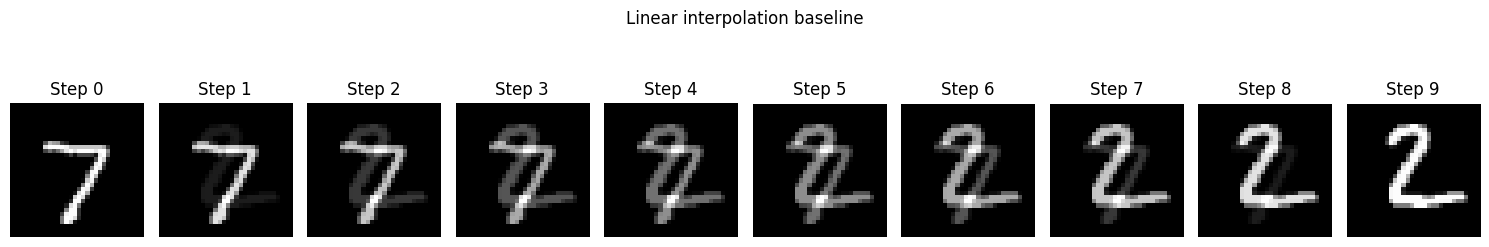

In [12]:
def linear_interpolation(x_a,x_b,steps=10):

    trajectory=[]

    for t in torch.linspace(0,1,steps):

        z_t=(1-t)*x_a+t*x_b

        trajectory.append(z_t)


    return trajectory



linear_traj = linear_interpolation(
    x_a,
    x_b,
    steps=10
)


show_trajectory(
    linear_traj,
    "Linear interpolation baseline"
)

### Experiment 2: Original RF Sampling (Reference)

For comparison, we reproduce the original usage:

Gaussian noise → data sample

This represents the distribution the model was trained on.

In [13]:
@torch.no_grad()
def rf_sample(
    rf,
    noise,
    label,
    steps=50
):

    trajectory=[noise.clone()]

    z=noise.clone()

    dt=1/steps


    for i in range(steps,0,-1):

        t=torch.tensor(
            [i/steps],
            device=z.device
        )


        velocity = rf.model(
            z,
            t,
            label
        )


        z=z-dt*velocity

        trajectory.append(
            z.clone()
        )


    return trajectory

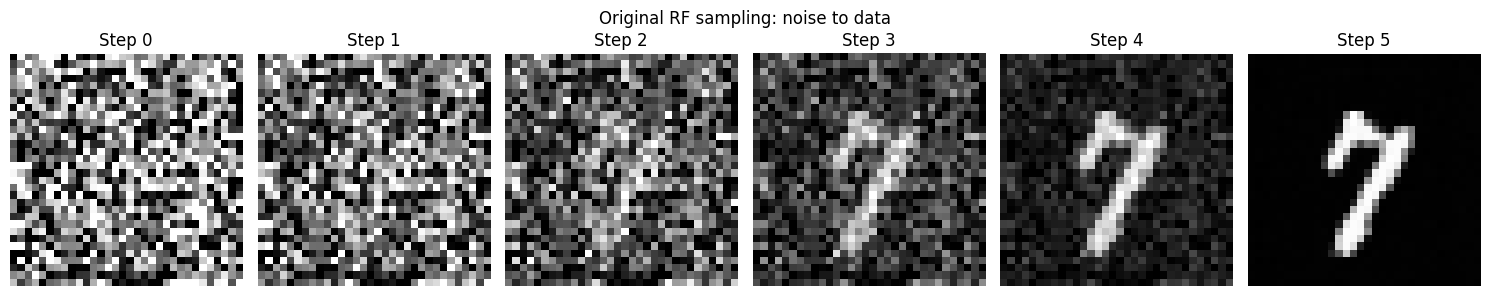

In [14]:
noise = torch.randn(
    1,
    1,
    32,
    32,
    device=device
)


label = torch.tensor(
    [label_a],
    device=device
)


noise_traj = rf_sample(
    rf,
    noise,
    label
)


show_trajectory(
    [
        noise_traj[i]
        for i in [0,10,20,30,40,50]
    ],
    "Original RF sampling: noise to data"
)

### Experiment 3: RF initialized from real data

The following experiment violates the original training assumption.

Instead of Gaussian noise, a real data sample is used as the starting point.

This tests whether the learned velocity field produces meaningful transformations in a data-to-data setting.

In [15]:
@torch.no_grad()
def rf_data_trajectory(
    rf,
    x_start,
    label,
    steps=50
):

    trajectory=[
        x_start.clone()
    ]

    z=x_start.clone()

    dt=1/steps


    for i in range(steps,0,-1):

        t=torch.tensor(
            [i/steps],
            device=z.device
        )


        velocity = rf.model(
            z,
            t,
            label
        )


        z=z-dt*velocity


        trajectory.append(
            z.clone()
        )


    return trajectory

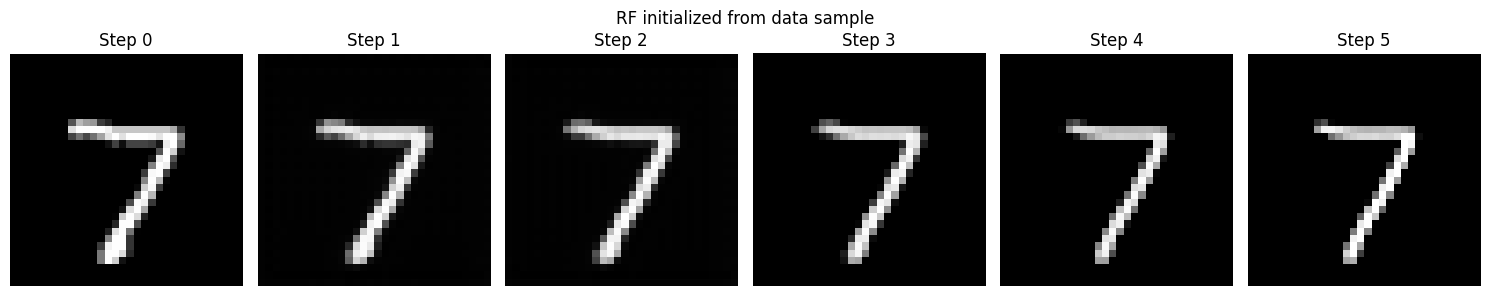

In [16]:
data_rf_traj = rf_data_trajectory(
    rf,
    x_a,
    label
)


show_trajectory(
    [
        data_rf_traj[i]
        for i in [0,10,20,30,40,50]
    ],
    "RF initialized from data sample"
)

## Evaluation of the Current Notebook Outputs

### Key Points

- **The setup is now consistent**: the repository origin points to the correct fork, and `checkpoint_99.pt` was found and loaded correctly.
- **Linear interpolation (digit 7 -> digit 2)** shows the expected pixel-space effect: intermediate states appear as overlap/ghosting of both digits.
- **Original RF sampling (Noise -> Data)** works as a sanity check: the trajectory moves from noise to a clear digit (here visually toward `7`).
- **RF with data initialization (Data -> ?)** stays close to the start image (`7`) and changes only slightly. There is **no clear transition to the target digit `2`**.
- Overall, the current results indicate: the model can perform its **trained task** (Noise->Data), but in this form it does **not provide reliable data-to-data interpolation**.

### Table: Interpretation of the Experiments

| Experiment | Output Observation | Interpretation | Relevance to Research Goal |
|---|---|---|---|
| Linear interpolation (A=7, B=2) | Visible ghosting/blending between 7 and 2 across steps | Typical pixel-space baseline effect, no learned dynamics | Useful reference baseline for comparison with RF behavior |
| Exp2: Original RF (Noise -> Data) | Strong noise transforms into a clear digit (visually 7) | Checkpoint and sampling work; model behaves plausibly in its trained domain | Confirms model functionality, but does not directly answer the data-to-data question |
| Exp3: RF from data init (start=7) | Steps remain visually close to 7, only minor transformation | OOD behavior: without suitable conditioning/training, there is no stable path from A to B | Central finding: current setup is insufficient for true data-to-data interpolation |

### Preliminary Conclusion for the Research Goal

- The current RF model is **functional** (Exp2), but results from Exp3 suggest that a model trained only on Noise->Data does **not automatically** act as a data-to-data interpolator.
- For stronger evidence, the analysis should be extended with quantitative metrics (e.g., class confidence over time, distance to start/target per step).

Observation

When initialized from a real MNIST sample instead of Gaussian noise, the pretrained Rectified Flow model does not produce meaningful transformations.

The generated trajectory remains close to the initial data point and mainly performs small refinements.

This behavior is expected because the model was trained exclusively on noise-to-data transport and has no objective that defines relationships between different data samples.

Therefore, the learned velocity field cannot directly be interpreted as a data-to-data interpolation mechanism.